## Simulate MOT Shim Coils
Jeff

## Program Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import magpylib as magpy
import arc
# from get_polarizability import *
from tqdm import tqdm
import scipy

## Build MOT Coils

In [2]:
# Useful B field functions
def plot_geometry_3d(sources):
    """
    Uses magpylib.show() to display geometry and adds two arrows with matplotlib
    to indicate current direction on each coil.
    """
    fig = magpy.show(sources, backend="matplotlib")  # returns matplotlib figure

    plt.show()

def make_thick_coil(
    radius, radial_thickness, axial_thickness,
    z_center, Nturns, I_per_turn,
    Nr=1, Nz=1,
):
    r_vals = np.linspace(
        radius - radial_thickness/2,
        radius + radial_thickness/2,
        Nr
    )

    if Nz == 1:
        z_vals = np.array([z_center])
    else:
        z_vals = np.linspace(
            z_center - axial_thickness/2,
            z_center + axial_thickness/2,
            Nz
        )

    loops = []
    turns_per_loop = Nturns / (Nr * Nz)

    for r in r_vals:
        for z0 in z_vals:
            loop = magpy.current.Circle(
                current=I_per_turn * turns_per_loop,
                diameter=2*r,
                position=(0, 0, z0),
            )
            loops.append(loop)

    return magpy.Collection(*loops)

def make_MOT_coils(I, plot=False):
    # Coil parameters
    wire_diameter = 4.4e-3 #4mm wire diameter
    average_radius = 78e-3/2 # (60+96)/2 = 78mm from center of coil to half radial thickness
    btb_coil_separation = 51.692e-3 #base of one coil (closest part to MOT) to the base of the other coil is 2.02in or 51.803 mm

    upper_MOT_base = make_thick_coil(
        average_radius, wire_diameter, wire_diameter,
        z_center= (btb_coil_separation/2) + 0.5*wire_diameter,
        Nturns=4, I_per_turn=I,
        Nr=4, Nz=1
    )

    upper_MOT_top = make_thick_coil(
        average_radius, wire_diameter, wire_diameter,
        z_center= (btb_coil_separation/2) + 1.5*wire_diameter,
        Nturns=3, I_per_turn=I,
        Nr=3, Nz=1
    )

    lower_MOT_base = make_thick_coil(
        average_radius, wire_diameter, wire_diameter,
        z_center= -(btb_coil_separation/2) - 0.5*wire_diameter,
        Nturns=4, I_per_turn=-I,
        Nr=4, Nz=1
    )

    lower_MOT_top = make_thick_coil(
        average_radius, wire_diameter, wire_diameter,
        z_center= -(btb_coil_separation/2) - 1.5*wire_diameter,
        Nturns=3, I_per_turn=-I,
        Nr=3, Nz=1
    )

    
    if plot:
        bases = upper_MOT_base + lower_MOT_base
        tops = upper_MOT_top + lower_MOT_top
        bases.style.color = 'red'
        tops.style.color = 'blue'
        plot_geometry_3d(bases)
        plot_geometry_3d(tops)
        plot_geometry_3d(bases + tops)
        print("Disable PLOT and run again to get the correct magpy object")
        return 0
    else:
        MOT_coils = upper_MOT_base + lower_MOT_base + upper_MOT_top + lower_MOT_top
        MOT_coils.style.color = 'red'
        return MOT_coils


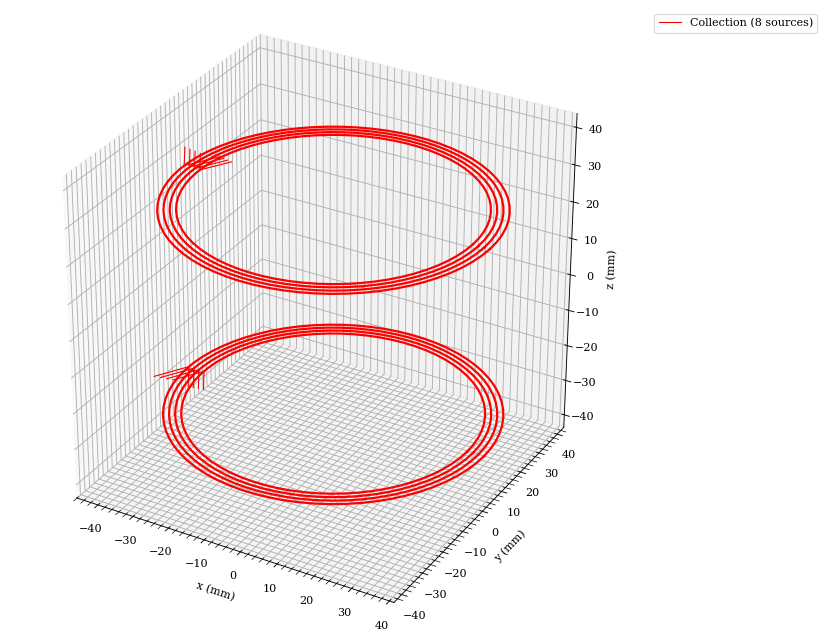

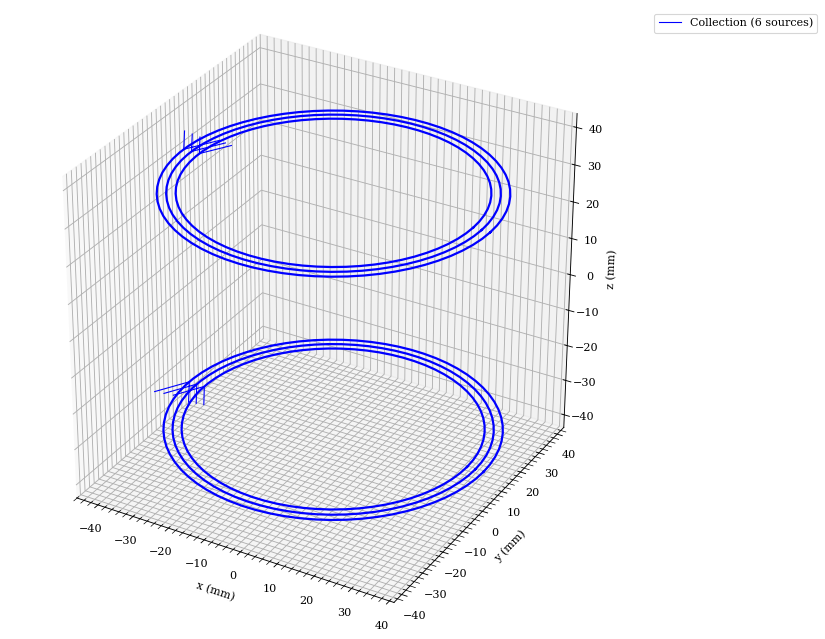

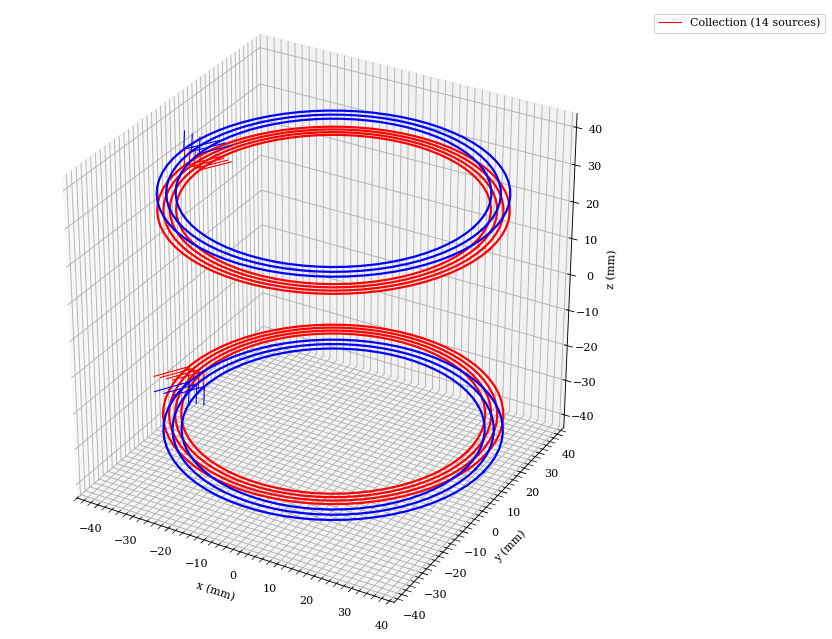

Disable PLOT and run again to get the correct magpy object


In [3]:
m_temp = make_MOT_coils(10, plot=True)

## Make big bias coils
In this notebook, I don't actually use this function.

In [4]:
def make_bias_coils(I, plot=False):
    # Coil parameters
    wire_diameter = 4e-3 #4mm wire diameter
    average_radius = 169.164e-3 # (6.13+7.19)/2 = 169.164mm from center of coil to half radial thickness
    total_height = 9.956e-3 # 0.392in is 9.956mm from the bottom of the coil stack to the top of the coil stack
    btb_coil_separation = 70.612e-3 #base of one coil (closest part to MOT) to the base of the other coil is 2.78in or 70.612 mm

    upper_bias = make_thick_coil(
        average_radius, wire_diameter, wire_diameter,
        z_center= (btb_coil_separation/2)+(total_height/2),
        Nturns=6, I_per_turn=I,
        Nr=3, Nz=2
    )

    lower_bias = make_thick_coil(
        average_radius, wire_diameter, wire_diameter,
        z_center= -(btb_coil_separation/2)-(total_height/2),
        Nturns=6, I_per_turn=-I,
        Nr=3, Nz=2
    )

    bias_coils = upper_bias + lower_bias
    bias_coils.style.color = 'purple'
    
    if plot:
        plot_geometry_3d(bias_coils)
        print("Disable PLOT and run again to get the correct magpy object")
        return 0
    else:
        return bias_coils



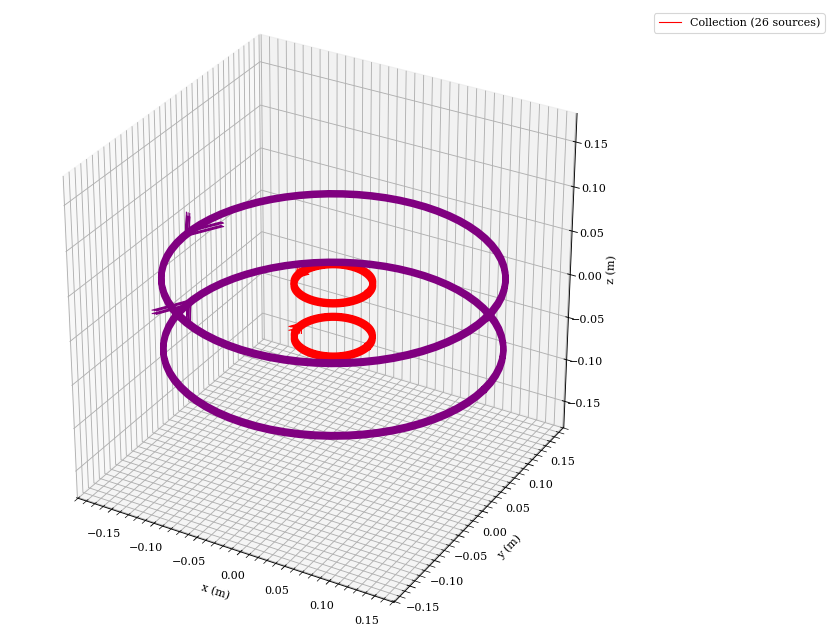

In [5]:
MOT_coils = make_MOT_coils(130, plot=False)
bias_coils = make_bias_coils(10, plot=False)
temp = magpy.Collection(MOT_coils, bias_coils)
plot_geometry_3d(temp)  

## Calculate B Field, cMOT configuration

In [6]:
### Constructing numpy array for places we want to calculate B
x_pos = np.linspace(-200e-3,200e-3,201)
y_pos = np.linspace(-200e-3,200e-3,201)
z_pos = np.linspace(-200e-3,200e-3,101)
X, Y, Z = np.meshgrid(x_pos, y_pos, z_pos, indexing="ij")
positions = np.stack([X, Y, Z], axis=-1)

### Finding B field
MOT_coils = make_MOT_coils(100, plot=False)
B_MOT = magpy.getB(MOT_coils, positions)

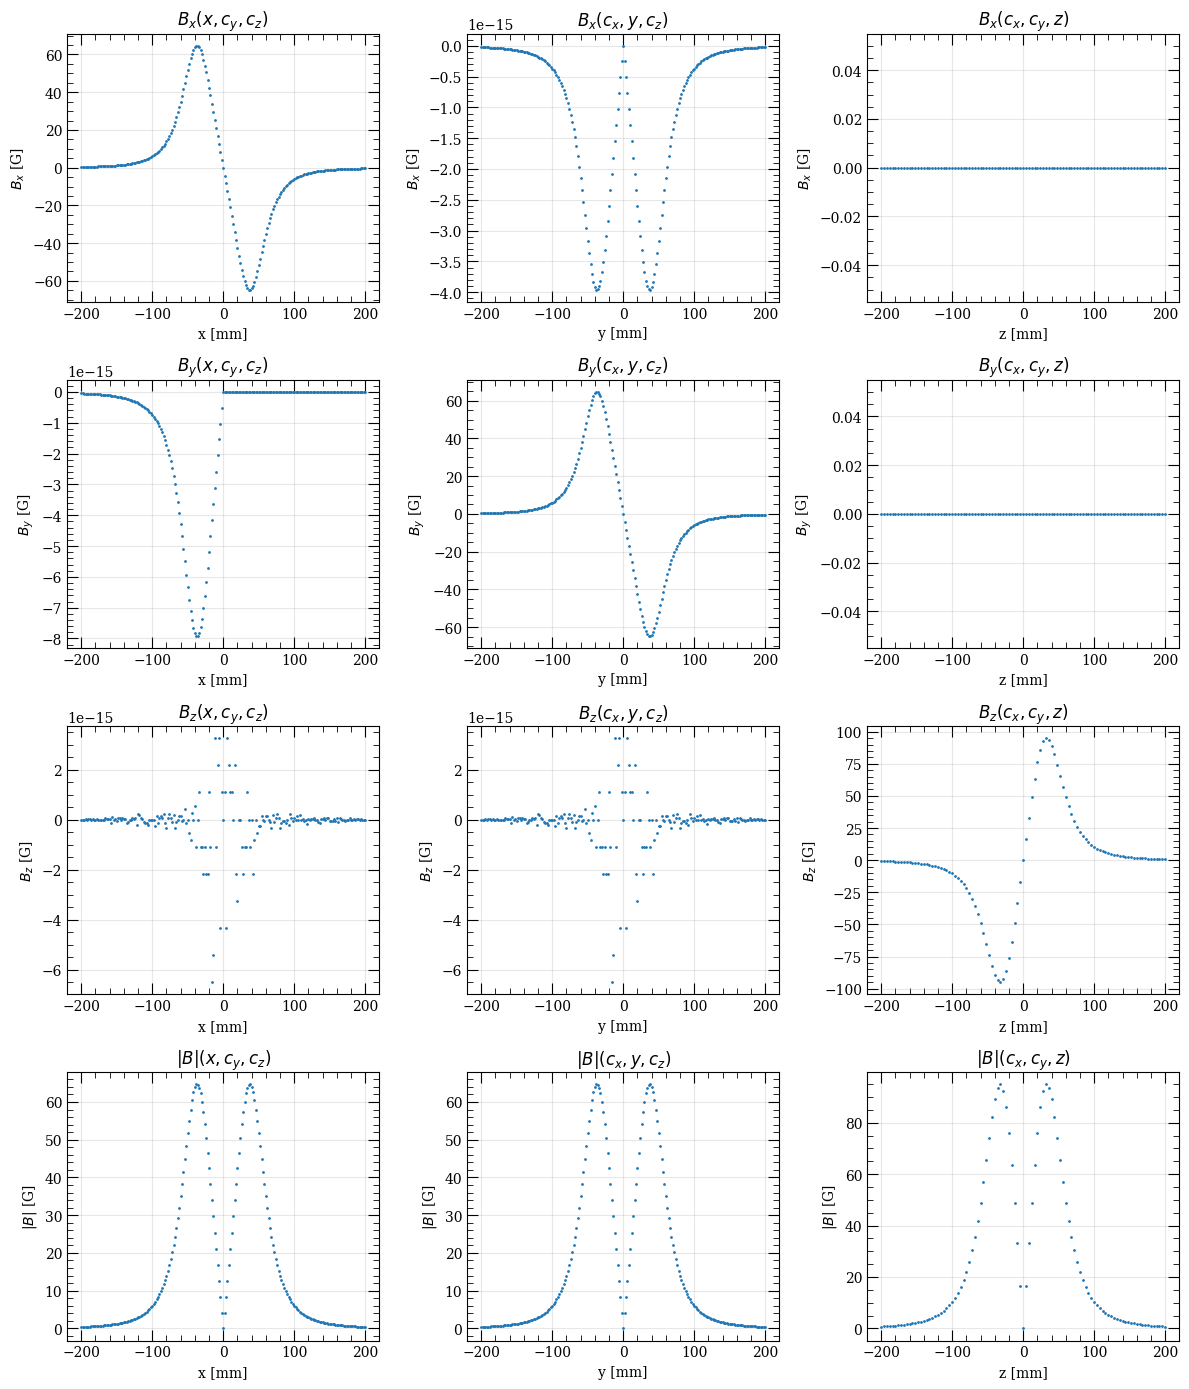

In [7]:
def plot_B_linecuts(x, y, z, Bx, By, Bz):
    """
    Plot 1D center-line cuts through a 3D magnetic field.

    Inputs
    ------
    x, y, z : 1D arrays of coordinates in meters
    Bx, By, Bz : 3D arrays with shape (Nx, Ny, Nz)

    Produces a 4x3 panel similar to your example.
    """
    # center indices
    cx = len(x) // 2
    cy = len(y) // 2
    cz = len(z) // 2

    # magnitude
    Bx = Bx*10000
    By = By*10000
    Bz = Bz*10000
    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

    # convert axes to mm for plotting
    xmm = x * 1e3
    ymm = y * 1e3
    zmm = z * 1e3

    fig, axes = plt.subplots(4, 3, figsize=(12, 14))
    axes = axes.ravel()

    # ---- Row 1: Bx ----
    axes[0].plot(xmm, Bx[:, cy, cz], '.', markersize=2)
    axes[0].set_title(r"$B_x(x,c_y,c_z)$")
    axes[0].set_xlabel("x [mm]")
    axes[0].set_ylabel(r"$B_x$ [G]")

    axes[1].plot(ymm, Bx[cx, :, cz], '.', markersize=2)
    axes[1].set_title(r"$B_x(c_x,y,c_z)$")
    axes[1].set_xlabel("y [mm]")
    axes[1].set_ylabel(r"$B_x$ [G]")

    axes[2].plot(zmm, Bx[cx, cy, :], '.', markersize=2)
    axes[2].set_title(r"$B_x(c_x,c_y,z)$")
    axes[2].set_xlabel("z [mm]")
    axes[2].set_ylabel(r"$B_x$ [G]")

    # ---- Row 2: By ----
    axes[3].plot(xmm, By[:, cy, cz], '.', markersize=2)
    axes[3].set_title(r"$B_y(x,c_y,c_z)$")
    axes[3].set_xlabel("x [mm]")
    axes[3].set_ylabel(r"$B_y$ [G]")

    axes[4].plot(ymm, By[cx, :, cz], '.', markersize=2)
    axes[4].set_title(r"$B_y(c_x,y,c_z)$")
    axes[4].set_xlabel("y [mm]")
    axes[4].set_ylabel(r"$B_y$ [G]")

    axes[5].plot(zmm, By[cx, cy, :], '.', markersize=2)
    axes[5].set_title(r"$B_y(c_x,c_y,z)$")
    axes[5].set_xlabel("z [mm]")
    axes[5].set_ylabel(r"$B_y$ [G]")

    # ---- Row 3: Bz ----
    axes[6].plot(xmm, Bz[:, cy, cz], '.', markersize=2)
    axes[6].set_title(r"$B_z(x,c_y,c_z)$")
    axes[6].set_xlabel("x [mm]")
    axes[6].set_ylabel(r"$B_z$ [G]")

    axes[7].plot(ymm, Bz[cx, :, cz], '.', markersize=2)
    axes[7].set_title(r"$B_z(c_x,y,c_z)$")
    axes[7].set_xlabel("y [mm]")
    axes[7].set_ylabel(r"$B_z$ [G]")

    axes[8].plot(zmm, Bz[cx, cy, :], '.', markersize=2)
    axes[8].set_title(r"$B_z(c_x,c_y,z)$")
    axes[8].set_xlabel("z [mm]")
    axes[8].set_ylabel(r"$B_z$ [G]")

    # ---- Row 4: |B| ----
    axes[9].plot(xmm, Bmag[:, cy, cz], '.', markersize=2)
    axes[9].set_title(r"$|B|(x,c_y,c_z)$")
    axes[9].set_xlabel("x [mm]")
    axes[9].set_ylabel(r"$|B|$ [G]")

    axes[10].plot(ymm, Bmag[cx, :, cz], '.', markersize=2)
    axes[10].set_title(r"$|B|(c_x,y,c_z)$")
    axes[10].set_xlabel("y [mm]")
    axes[10].set_ylabel(r"$|B|$ [G]")

    axes[11].plot(zmm, Bmag[cx, cy, :], '.', markersize=2)
    axes[11].set_title(r"$|B|(c_x,c_y,z)$")
    axes[11].set_xlabel("z [mm]")
    axes[11].set_ylabel(r"$|B|$ [G]")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

Bx_MOT = B_MOT[..., 0]
By_MOT = B_MOT[..., 1]
Bz_MOT = B_MOT[..., 2]
plot_B_linecuts(x_pos, y_pos, z_pos, Bx_MOT, By_MOT, Bz_MOT)

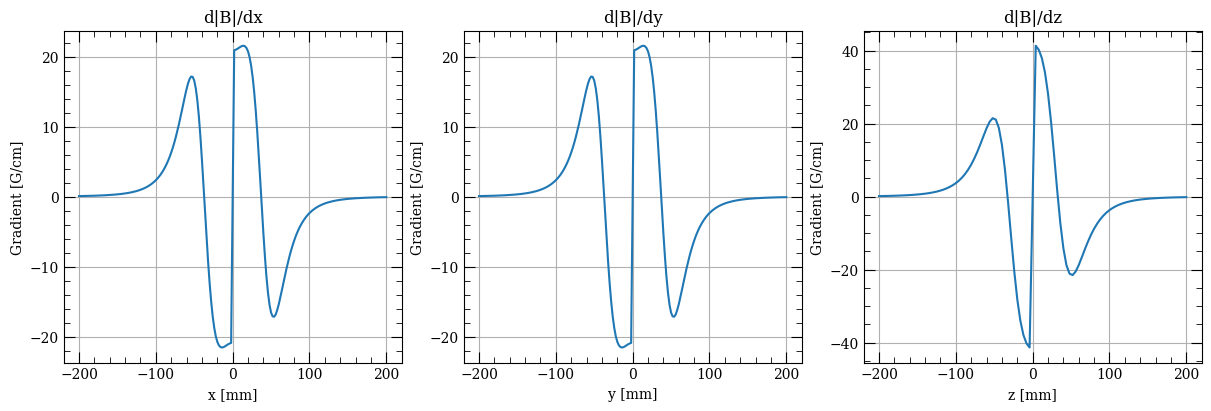

In [8]:
Bmag = np.sqrt(Bx_MOT**2 + By_MOT**2 + Bz_MOT**2)

# Grid spacings
dx = x_pos[1] - x_pos[0]
dy = y_pos[1] - y_pos[0]
dz = z_pos[1] - z_pos[0]

# Compute gradients explicitly along the 3 spatial axes
dB_dx, dB_dy, dB_dz = np.gradient(Bmag, dx, dy, dz, axis=(0, 1, 2), edge_order=2)

# Center indices
cx = len(x_pos) // 2
cy = len(y_pos) // 2
cz = len(z_pos) // 2

# Axes in mm
x_mm = x_pos * 1e3
y_mm = y_pos * 1e3
z_mm = z_pos * 1e3

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

axes[0].plot(x_mm, dB_dx[:, cy, cz]*100)
axes[1].plot(y_mm, dB_dy[cx, :, cz]*100)
axes[2].plot(z_mm, dB_dz[cx, cy, :]*100)

titles = [
    'd|B|/dx', 'd|B|/dy', 'd|B|/dz',
]

xlabels = [
    'x [mm]', 'y [mm]', 'z [mm]',
]

for ax, title, xlabel in zip(axes.ravel(), titles, xlabels):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Gradient [G/cm]')
    ax.grid(True)

plt.show()

In [9]:
# What is the B field 5mm from the B field zero?
B_MOT_5mm = magpy.getB(MOT_coils, (5e-3/np.sqrt(2),5e-3/np.sqrt(2),0))
print(f"B_x = {B_MOT_5mm[0]*10000} Gauss")
print(f"B_y = {B_MOT_5mm[1]*10000} Gauss")
print(f"B_z = {B_MOT_5mm[2]*10000} Gauss")

B_x = -7.4020041489673405 Gauss
B_y = -7.4020041489673405 Gauss
B_z = 1.0842021724855044e-15 Gauss


## Shim coil setup

In [10]:
def make_thick_coil_arbaxis(
    radius,
    radial_thickness,
    axial_thickness,
    center=(0.0, 0.0, 0.0),
    axis=(0.0, 0.0, 1.0),
    Nturns=1,
    I_per_turn=1.0,
    Nr=1,
    Nz=1,
):
    center = np.asarray(center, dtype=float)
    axis = np.asarray(axis, dtype=float)

    axis_norm = np.linalg.norm(axis)
    if axis_norm == 0:
        raise ValueError("axis must be a nonzero vector")
    axis = axis / axis_norm

    # IMPORTANT: if only one sample, place it at the center
    if Nr == 1:
        r_vals = np.array([radius], dtype=float)
    else:
        r_vals = np.linspace(
            radius - radial_thickness / 2,
            radius + radial_thickness / 2,
            Nr,
        )

    if Nz == 1:
        z_vals = np.array([0.0], dtype=float)
    else:
        z_vals = np.linspace(
            -axial_thickness / 2,
            +axial_thickness / 2,
            Nz,
        )

    turns_per_loop = Nturns / (Nr * Nz)
    loops = []

    for r in r_vals:
        for z0 in z_vals:
            loop = magpy.current.Circle(
                current=I_per_turn * turns_per_loop,
                diameter=2 * r,
                position=(0.0, 0.0, z0),
            )
            loops.append(loop)

    coil = magpy.Collection(*loops)

    zhat = np.array([0.0, 0.0, 1.0])

    if np.allclose(axis, zhat):
        rot = scipy.spatial.transform.Rotation.identity()
    elif np.allclose(axis, -zhat):
        rot = scipy.spatial.transform.Rotation.from_rotvec(
            np.pi * np.array([1.0, 0.0, 0.0])
        )
    else:
        rot_axis = np.cross(zhat, axis)
        rot_axis = rot_axis / np.linalg.norm(rot_axis)
        angle = np.arccos(np.clip(np.dot(zhat, axis), -1.0, 1.0))
        rot = scipy.spatial.transform.Rotation.from_rotvec(angle * rot_axis)

    coil.rotate(rot)
    coil.move(center)

    return coil

def make_shims(I=5, distance_between_coils = 200e-3, coil_inner_diameter= 70e-3, Nturns=1, Nr=1, Nz=1, plot=False):
    wire_diameter = 1.3e-3 #Just guess we want a single stack of 16 gauge wire
    
    ax1_shim1 = make_thick_coil_arbaxis(radius = coil_inner_diameter/2+(wire_diameter/2),
        radial_thickness = wire_diameter,
        axial_thickness = wire_diameter,
        center = (distance_between_coils/np.sqrt(2),distance_between_coils/np.sqrt(2),0),
        axis = (1,1,0),
        Nturns = Nturns,
        Nr = Nr,
        Nz = Nz,
        I_per_turn = I
        )
    
    ax1_shim2 = make_thick_coil_arbaxis( radius = coil_inner_diameter/2+(wire_diameter/2),
        radial_thickness = wire_diameter,
        axial_thickness = wire_diameter,
        center = (-distance_between_coils/np.sqrt(2),-distance_between_coils/np.sqrt(2),0),
        axis = (1,1,0),
        Nturns = Nturns,
        Nr = Nr,
        Nz = Nz,
        I_per_turn = I
        )
    
    ax2_shim1 = make_thick_coil_arbaxis(radius = coil_inner_diameter/2+(wire_diameter/2),
        radial_thickness = wire_diameter,
        axial_thickness = wire_diameter,
        center = (-distance_between_coils/np.sqrt(2),distance_between_coils/np.sqrt(2),0),
        axis = (1,-1,0),
        Nturns = Nturns,
        Nr = Nr,
        Nz = Nz,
        I_per_turn = I
        )
    
    ax2_shim2 = make_thick_coil_arbaxis( radius = coil_inner_diameter/2+(wire_diameter/2),
        radial_thickness = wire_diameter,
        axial_thickness = wire_diameter,
        center = (distance_between_coils/np.sqrt(2),-distance_between_coils/np.sqrt(2),0),
        axis = (1,-1,0),
        Nturns = Nturns,
        Nr = Nr,
        Nz = Nz,
        I_per_turn = I
        )
    
    op2_shim_coils = ax1_shim1 + ax1_shim2 + ax2_shim1 + ax2_shim2
    op2_shim_coils.style.color = 'orange'
    if plot:
        plot_geometry_3d(op2_shim_coils)
        print("Disable PLOT and run again to get the correct magpy object")
        return 0
    else:
        return op2_shim_coils
    

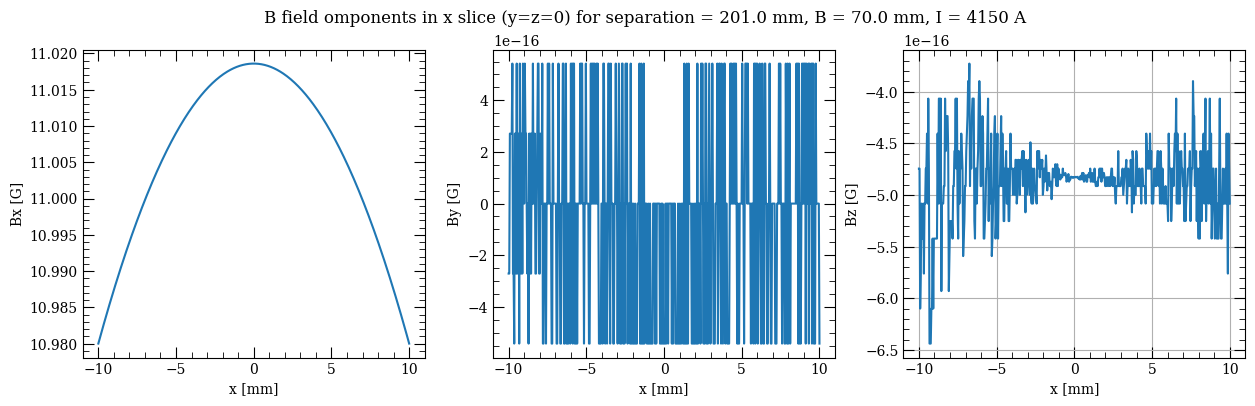

In [11]:
# Hunting for optimal size

# Position scan
xtemp_pos = np.linspace(-10e-3, 10e-3, 500)
ytemp_pos = 0
ztemp_pos = 0
X, Y, Z = np.meshgrid(xtemp_pos, ytemp_pos, ztemp_pos, indexing="ij")
scan_positions = np.stack([X, Y, Z], axis=-1)

coil_diameter = 70e-3
distance_bw_coils = 201e-3
current = 4150
shims = make_shims(coil_inner_diameter=coil_diameter, distance_between_coils = distance_bw_coils, I=current, Nturns=1)

B_shim_scan = magpy.getB(shims, scan_positions)
B_shim = B_shim_scan*10000

# Extract components (shape: (Nx,1,1,3) -> flatten to (Nx,))
Bx = B_shim[..., 0].squeeze()
By = B_shim[..., 1].squeeze()
Bz = B_shim[..., 2].squeeze()

# Convert x-axis to mm for plotting
x_mm = xtemp_pos * 1e3

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].plot(x_mm, Bx, label="Bx")
axes[0].set_xlabel("x [mm]")
axes[0].set_ylabel("Bx [G]")

axes[1].plot(x_mm, By, label="By")
axes[1].set_xlabel("x [mm]")
axes[1].set_ylabel("By [G]")

axes[2].plot(x_mm, Bz, label="Bz")
axes[2].set_xlabel("x [mm]")
axes[2].set_ylabel("Bz [G]")

fig.suptitle(f"B field omponents in x slice (y=z=0) for separation = {distance_bw_coils*1e3} mm, B = {coil_diameter*1e3} mm, I = {current} A")
plt.grid(True)

plt.show()

## Option 2 coil setup, two sets of square coils

In [12]:
def make_thick_square_coil_arbaxis(
    radius,
    radial_thickness,
    axial_thickness,
    center=(0.0, 0.0, 0.0),
    axis=(0.0, 0.0, 1.0),
    Nturns=1,
    I_per_turn=1.0,
    Nr=1,
    Nz=1,
):
    center = np.asarray(center, dtype=float)
    axis = np.asarray(axis, dtype=float)

    axis_norm = np.linalg.norm(axis)
    if axis_norm == 0:
        raise ValueError("axis must be a nonzero vector")
    axis = axis / axis_norm

    if Nr == 1:
        r_vals = np.array([radius], dtype=float)
    else:
        r_vals = np.linspace(
            radius - radial_thickness / 2,
            radius + radial_thickness / 2,
            Nr,
        )

    if Nz == 1:
        z_vals = np.array([0.0], dtype=float)
    else:
        z_vals = np.linspace(
            -axial_thickness / 2,
            +axial_thickness / 2,
            Nz,
        )

    turns_per_loop = Nturns / (Nr * Nz)
    loops = []

    # 45° rotation in the xy-plane
    rot45 = scipy.spatial.transform.Rotation.from_rotvec(
        np.pi/4 * np.array([0.0, 0.0, 1.0])
    )

    for r in r_vals:
        side = 2 * r
        h = side / 2

        # axis-aligned square
        vertices_xy = np.array([
            [-h, -h, 0.0],
            [ h, -h, 0.0],
            [ h,  h, 0.0],
            [-h,  h, 0.0],
            [-h, -h, 0.0],
        ])

        # rotate square by 45° about z
        vertices_xy = rot45.apply(vertices_xy)

        for z0 in z_vals:
            vertices = vertices_xy + np.array([0.0, 0.0, z0])

            loop = magpy.current.Polyline(
                current=I_per_turn * turns_per_loop,
                vertices=vertices,
            )
            loops.append(loop)

    coil = magpy.Collection(*loops)

    zhat = np.array([0.0, 0.0, 1.0])

    if np.allclose(axis, zhat):
        rot = scipy.spatial.transform.Rotation.identity()
    elif np.allclose(axis, -zhat):
        rot = scipy.spatial.transform.Rotation.from_rotvec(
            np.pi * np.array([1.0, 0.0, 0.0])
        )
    else:
        rot_axis = np.cross(zhat, axis)
        rot_axis = rot_axis / np.linalg.norm(rot_axis)
        angle = np.arccos(np.clip(np.dot(zhat, axis), -1.0, 1.0))
        rot = scipy.spatial.transform.Rotation.from_rotvec(angle * rot_axis)

    coil.rotate(rot)
    coil.move(center)

    return coil

def make_square_shims(I=5, distance_between_coils = 200e-3, coil_inner_diameter= 70e-3, Nturns=1, Nr=1, Nz=1, plot=False):
    wire_diameter = 1.3e-3 #Just guess we want a single stack of 16 gauge wire
    
    ax1_shim1 = make_thick_square_coil_arbaxis(radius = coil_inner_diameter/2+(wire_diameter/2),
        radial_thickness = wire_diameter,
        axial_thickness = wire_diameter,
        center = (distance_between_coils/np.sqrt(2),distance_between_coils/np.sqrt(2),0),
        axis = (1,1,0),
        Nturns = Nturns,
        Nr = Nr,
        Nz = Nz,
        I_per_turn = I
        )
    
    ax1_shim2 = make_thick_square_coil_arbaxis( radius = coil_inner_diameter/2+(wire_diameter/2),
        radial_thickness = wire_diameter,
        axial_thickness = wire_diameter,
        center = (-distance_between_coils/np.sqrt(2),-distance_between_coils/np.sqrt(2),0),
        axis = (1,1,0),
        Nturns = Nturns,
        Nr = Nr,
        Nz = Nz,
        I_per_turn = I
        )
    
    ax2_shim1 = make_thick_square_coil_arbaxis(radius = coil_inner_diameter/2+(wire_diameter/2),
        radial_thickness = wire_diameter,
        axial_thickness = wire_diameter,
        center = (-distance_between_coils/np.sqrt(2),distance_between_coils/np.sqrt(2),0),
        axis = (1,-1,0),
        Nturns = Nturns,
        Nr = Nr,
        Nz = Nz,
        I_per_turn = I
        )
    
    ax2_shim2 = make_thick_square_coil_arbaxis( radius = coil_inner_diameter/2+(wire_diameter/2),
        radial_thickness = wire_diameter,
        axial_thickness = wire_diameter,
        center = (distance_between_coils/np.sqrt(2),-distance_between_coils/np.sqrt(2),0),
        axis = (1,-1,0),
        Nturns = Nturns,
        Nr = Nr,
        Nz = Nz,
        I_per_turn = I
        )
    
    op2_shim_coils = ax1_shim1 + ax1_shim2 + ax2_shim1 + ax2_shim2
    op2_shim_coils.style.color = 'purple'
    if plot:
        plot_geometry_3d(op2_shim_coils)
        print("Disable PLOT and run again to get the correct magpy object")
        return 0
    else:
        return op2_shim_coils
    

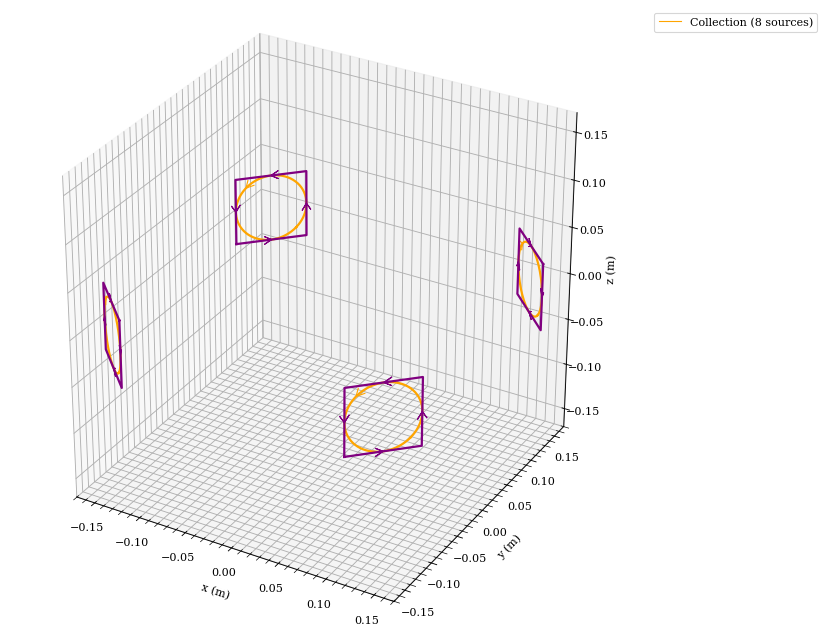

In [13]:
coil_diameter = 70e-3
distance_bw_coils = 201e-3
current = 4150
square_shims = make_square_shims(coil_inner_diameter=coil_diameter, distance_between_coils = distance_bw_coils, I=current, Nturns=1)
temp = magpy.Collection(shims, square_shims)
plot_geometry_3d(temp)

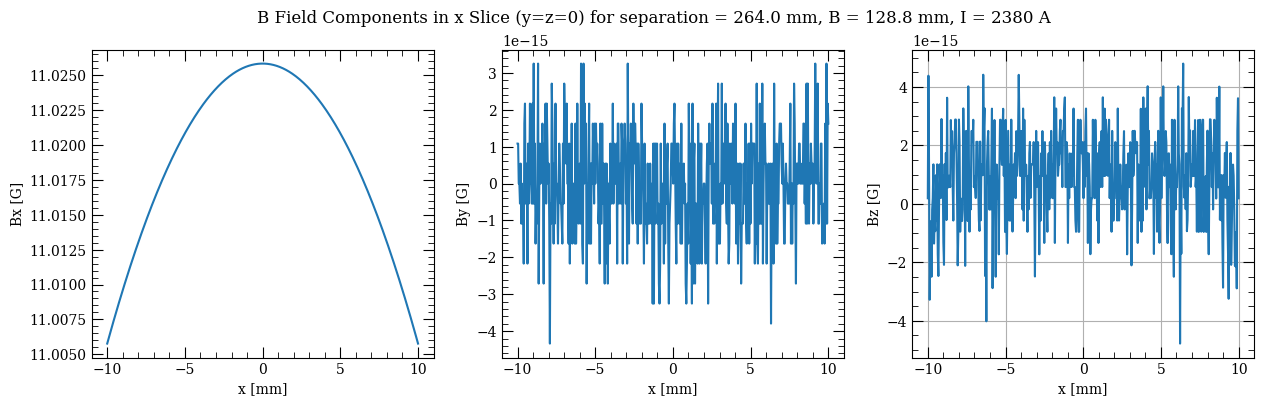

In [14]:
# Hunting for optimal size

# Position scan
xtemp_pos = np.linspace(-10e-3, 10e-3, 500)
ytemp_pos = 0
ztemp_pos = 0
X, Y, Z = np.meshgrid(xtemp_pos, ytemp_pos, ztemp_pos, indexing="ij")
scan_positions = np.stack([X, Y, Z], axis=-1)

coil_diameter = 128.8e-3
distance_bw_coils = 264e-3
current = 2380
square_shims = make_square_shims(coil_inner_diameter=coil_diameter, distance_between_coils = distance_bw_coils, I=current, Nturns=1)

B_shim2_scan = magpy.getB(square_shims, scan_positions)
B_shim2 = B_shim2_scan*10000

# Extract components (shape: (Nx,1,1,3) -> flatten to (Nx,))
Bx2 = B_shim2[..., 0].squeeze()
By2 = B_shim2[..., 1].squeeze()
Bz2 = B_shim2[..., 2].squeeze()

# Convert x-axis to mm for plotting
x_mm = xtemp_pos * 1e3

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].plot(x_mm, Bx2, label="Bx")
axes[0].set_xlabel("x [mm]")
axes[0].set_ylabel("Bx [G]")

axes[1].plot(x_mm, By2, label="By")
axes[1].set_xlabel("x [mm]")
axes[1].set_ylabel("By [G]")

axes[2].plot(x_mm, Bz2, label="Bz")
axes[2].set_xlabel("x [mm]")
axes[2].set_ylabel("Bz [G]")

fig.suptitle(f"B Field Components in x Slice (y=z=0) for separation = {distance_bw_coils*1e3} mm, B = {coil_diameter*1e3} mm, I = {current} A")
plt.grid(True)

plt.show()